In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

subgraph_llm = ChatOpenAI()

In [3]:
#state
class SubgraphState(TypedDict):
    input_text: str
    translated_text: str
    
#Node
def translate(state: SubgraphState) -> SubgraphState:
    prompt = f"""You are helpful assistant to convert provided statement to Hindi text. 
    Translation needs to be neat and clean. 
    Do not add any extra line. 
    Statement: {state['input_text']}"""
    
    response = subgraph_llm.invoke(prompt).content
    
    return {"translated_text" : response}

In [4]:
graph = StateGraph(SubgraphState)

graph.add_node("translate",translate)

graph.add_edge(START,'translate')
graph.add_edge('translate',END)

subgraph = graph.compile()

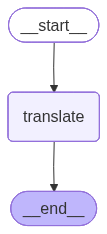

In [5]:
subgraph

In [ ]:
# initial_state = {"input_text" :"Learning something new every day keeps the mind active and curious. Whether it is reading a book, observing nature, or solving a small problem, each experience adds value. Consistency matters more than perfection. Even small steps can lead to meaningful growth over time. Staying patient and open to change helps in adapting to new challenges and opportunities."}
# subresult = subgraph.invoke(initial_state)

In [ ]:
#print(subresult)

In [6]:
##### main workflow
main_flow = ChatOpenAI()

class MainState(TypedDict):
    topic: str
    blog_text: str
    translated_blog_text: str
    
def blog_generate(state: MainState):
    prompt = f"""Generate a blog on user provided topic. Blog must have 100 words long only.
                Topic: {state.get("topic")}
                """
                
    blog = main_flow.invoke(prompt).content
    
    return {"blog_text" : blog}

def blog_translate(state: MainState):
    
    subgraph_result = subgraph.invoke({"input_text":state.get("blog_text")})
    
    translated_text = subgraph_result.get("translated_text")
    
    return {"translated_blog_text" : translated_text}

main_graph = StateGraph(MainState)

main_graph.add_node('blog_generate',blog_generate)
main_graph.add_node('blog_translate',blog_translate)

main_graph.add_edge(START,'blog_generate')
main_graph.add_edge('blog_generate','blog_translate')
main_graph.add_edge('blog_translate',END)

MainGraph = main_graph.compile()

In [7]:
initial_state = {"topic" : "Write a blog on tiger."}
result = MainGraph.invoke(initial_state)

In [8]:
result

{'topic': 'Write a blog on tiger.',
 'blog_text': "The tiger is a magnificent and powerful creature that roams the jungles of Asia. With its iconic orange coat and black stripes, the tiger is a symbol of strength and beauty in the animal kingdom. Unfortunately, tigers are also facing serious threats from habitat loss and poaching.\n\nThere are several different subspecies of tigers, including the Bengal tiger, the Siberian tiger, and the Sumatran tiger. Each subspecies has its own unique characteristics and adaptations. Tigers are solitary animals, hunting and living on their own, except for when females are caring for their young.\n\nDespite their fearsome reputation, tigers are actually quite shy and elusive creatures. They are incredibly agile and can run at high speeds, making them formidable hunters. It is important that we work to protect these incredible animals and ensure their survival in the wild. Let's do our part to save the tigers for future generations to enjoy.",
 'trans